In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
import scipy.optimize as opt
matplotlib.rcParams.update({'font.size': 13})
matplotlib.rcParams['lines.linewidth'] = 2


light_green = (0.4, 0.8, 0.2)
dark_purple = (0.4, 0.3, 0.7)
raspberry_pink = (1, 0, 0.5)



# A. измерение ширины щели 
## 1. геометрическая оптика


In [ ]:
#увеличение линзы
L = 136 #cm
delta_L = 0.5 #cm
b1 = 131 #cm
delta_b1 = 0.5 #cm
F2 = 3.8 #cm

#способ 1
a1 = L - b1
delta_a1 = (delta_L**2 + delta_b1**2)**0.5
print(a1, delta_a1)
gamma1 = b1/a1
delta_gamma1 = ((delta_b1/b1)**2 + (delta_a1/a1)**2)**0.5 * gamma1
print("способ 1: ", gamma1, delta_gamma1)

#способ 2
a1 = F2*b1/(b1 - F2)
delta_a1 = a1 * ((delta_b1/b1)**2 + (delta_b1/(b1 - F2))**2)**0.5
print(a1, delta_a1)
gamma2 = b1/a1
delta_gamma2 = ((delta_b1/b1)**2 + (delta_a1/a1)**2)**0.5 * gamma2
print("способ 2: ", gamma2, delta_gamma2)

5 0.7071067811865476
способ 1:  26.2 3.706588728197397
3.913522012578616 0.02144211628848596
способ 2:  33.47368421052632 0.22351589453967138


In [50]:
#измерения
dataA1 = pd.read_excel("измерения.xlsx", sheet_name="А1", skiprows=1)
dataA1

,"x, mkm*10","D1, cm","delta D1, cm",Unnamed: 3,Unnamed: 4,131,0.5
0,0,0.2,0.1,NaN,NaN,NaN,NaN
1,10,0.2,NaN,NaN,NaN,NaN,NaN
2,20,0.5,NaN,NaN,NaN,NaN,NaN
3,30,0.6,NaN,NaN,NaN,NaN,NaN
4,40,0.8,NaN,NaN,NaN,NaN,NaN
5,50,1.2,NaN,NaN,NaN,NaN,NaN
6,60,1.4,NaN,NaN,NaN,NaN,NaN
7,70,1.6,NaN,NaN,NaN,NaN,NaN
8,80,1.9,NaN,NaN,NaN,NaN,NaN
9,90,2.2,NaN,NaN,NaN,NaN,NaN


7.631177880084978


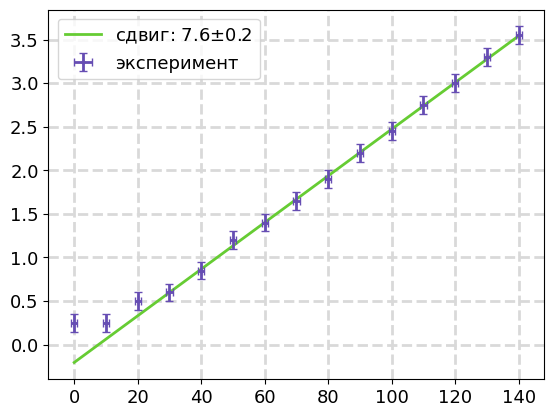

In [51]:
delta_D1 = 0.1 #cm
delta_x = 1 #mkm*10

#расчет люфта

def linear(x, k, b):
    return k*x + b
popt, pcov = opt.curve_fit(linear, 
                             dataA1["x, mkm*10"].iloc[3:], 
                             dataA1["D1, cm"].iloc[3:], 
                             sigma = [delta_D1]*(len(dataA1)-3), 
                             absolute_sigma = True)
k = popt[0]
b = popt[1]
delta_k = pcov[0][0]
delta_b = pcov[1][1]

x0 = -b/k
delta_x0 = x0 * ((delta_k/k)**2+(delta_b/b)**2)**0.5
print(x0)

x_th = np.linspace(0, 140, 2)

plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)
plt.plot(x_th, k * x_th + b, 
         color = light_green, 
         label = f"сдвиг: {x0:.1f}" + r"$\pm$" + f"{delta_x0:.1f}")

plt.errorbar(dataA1["x, mkm*10"], dataA1["D1, cm"], 
             xerr = delta_x, yerr = delta_D1, 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             label = 'эксперимент',
             color = dark_purple)
#plt.ylabel()
#plt.xlabel()
plt.legend()

In [52]:
#расчет теоретической ширины и сравнение с практикой
dataA1["D, mm"] = (dataA1["x, mkm*10"] - x0)/100
delta_D = (delta_x**2 + delta_x0**2)**0.5/100
dataA1["Dл, mm"] = (dataA1["D1, cm"])/gamma1*10
dataA1["delta_Dл, mm"] = dataA1["Dл, mm"]*((delta_D1/dataA1["D1, cm"])**2 + (delta_gamma1/gamma1)**2)**0.5
dataA1_final = dataA1[["D, mm","D1, cm", "Dл, mm", "delta_Dл, mm"]].iloc[2:]
pd.set_option('display.precision', 2)
print(delta_D)
dataA1_final

0.010238925668353015


,"D, mm","D1, cm","Dл, mm","delta_Dл, mm"
2,0.12,0.50,0.19,0.05
3,0.22,0.60,0.23,0.05
4,0.32,0.85,0.32,0.06
5,0.42,1.20,0.46,0.08
6,0.52,1.40,0.53,0.08
7,0.62,1.65,0.63,0.10
8,0.72,1.90,0.73,0.11
9,0.82,2.20,0.84,0.12
10,0.92,2.45,0.94,0.14
11,1.02,2.75,1.05,0.15


## 2. дифракция Фраунгофера

In [53]:
# измерения
dataA2 = pd.read_excel("измерения.xlsx", sheet_name="A2").rename(columns={"m (порядок максимума (придется думать головой))": "m"}).drop(index=[0])
dataA2

,"X, cm",m,"x, 10*mkm",Unnamed: 3,Unnamed: 4,Unnamed: 5,"x0, 10*mkm","L, cm","delta L, cm"
1,15.5,5.0,14,0.71,NaN,NaN,NaN,NaN,NaN
2,12.8,8.0,18,1.33,NaN,NaN,NaN,NaN,NaN
3,12.0,9.0,20,1.58,NaN,NaN,NaN,NaN,NaN
4,11.5,10.0,22,1.83,NaN,NaN,NaN,NaN,NaN
5,10.2,10.0,24,2.06,NaN,NaN,NaN,NaN,NaN
6,8.8,10.0,26,2.39,NaN,NaN,NaN,NaN,NaN
7,8.0,10.0,28,2.62,NaN,NaN,NaN,NaN,NaN
8,7.4,10.0,30,2.84,NaN,NaN,NaN,NaN,NaN
9,6.1,10.0,34,3.44,NaN,NaN,NaN,NaN,NaN
10,12.0,6.0,16,1.08,NaN,NaN,NaN,NaN,NaN


In [54]:
#длина волны лазера
lam = 6326#a
dataA2["D, mkm*10"] = (dataA2["x, 10*mkm"] - x0)
# пересчет максимумов в минимумы
dataA2["Dx, mm"] = dataA2["X, cm"]/(2 * dataA2["m"] - 1)*10
dataA2["delta_Dx, mm"] = dataA2["Dx, mm"]**2/dataA2["X, cm"]/10
dataA2["Ds, mkm*10"] = lam * L / dataA2["Dx, mm"] * 1e-4
dataA2["delta_Ds, mkm*10"] = ((delta_L/L)**2 + (dataA2["delta_Dx, mm"]/dataA2["Dx, mm"])**2)**0.5 * dataA2["Ds, mkm*10"]
dataA2_final = dataA2[["D, mkm*10","Dx, mm", "delta_Dx, mm", "Ds, mkm*10", "delta_Ds, mkm*10"]]
pd.set_option('display.precision', 1)
dataA2_final

,"D, mkm*10","Dx, mm","delta_Dx, mm","Ds, mkm*10","delta_Ds, mkm*10"
1,6.4,17.2,1.9,5.0,0.6
2,10.4,8.5,0.6,10.1,0.7
3,12.4,7.1,0.4,12.2,0.7
4,14.4,6.1,0.3,14.2,0.7
5,16.4,5.4,0.3,16.0,0.8
6,18.4,4.6,0.2,18.6,1.0
7,20.4,4.2,0.2,20.4,1.1
8,22.4,3.9,0.2,22.1,1.2
9,26.4,3.2,0.2,26.8,1.4
10,8.4,10.9,1.0,7.9,0.7


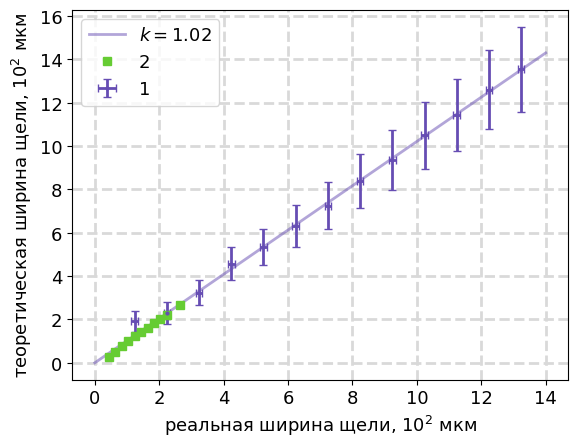

In [69]:
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)

D_th = np.linspace(0, 14)
#plt.plot(D_want, D_want, '--',
#         color = (0.85, 0.85, 0.85))
def linear0(x, k):
    return k*x
popt, pcov = opt.curve_fit(linear0, 
                             dataA1_final["D, mm"].iloc[1:], 
                             dataA1_final["Dл, mm"].iloc[1:], 
                             sigma = dataA1_final["delta_Dл, mm"].iloc[1:], 
                             absolute_sigma = True)
k = popt[0]
delta_k = pcov[0][0]

plt.plot(D_th, k*D_th,
         color = dark_purple, alpha = 0.5,
         label = r"$k = $" + f"{k:.2f}")

plt.errorbar(dataA1_final["D, mm"] * 10, dataA1_final["Dл, mm"] * 10, 
             xerr = delta_D * 10, yerr = dataA1_final["delta_Dл, mm"] * 10, 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             label = '1',
             color = dark_purple)
plt.plot(dataA2_final["D, mkm*10"] / 10, dataA2_final["Ds, mkm*10"] / 10, 's', 
             label = '2',
             color = light_green)
#plt.title('Расчет ширины щели по:\n (1) ее увеличенному изображению на экране')
plt.xlabel('реальная ширина щели, ' + r'$10^2$ мкм')
plt.ylabel('теоретическая ширина щели, ' + r'$10^2$ мкм')
plt.legend()
plt.savefig('pics/A_plot.png', dpi=300)


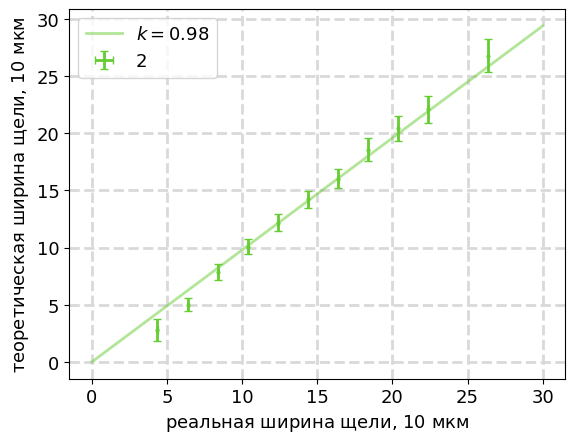

In [76]:
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)

D_th = np.linspace(0, 30)
#plt.plot(D_want, D_want, '--',
#         color = (0.85, 0.85, 0.85))
def linear0(x, k):
    return k*x
popt, pcov = opt.curve_fit(linear0, 
                             dataA2_final["D, mkm*10"], 
                             dataA2_final["Ds, mkm*10"], 
                             sigma = dataA2_final["delta_Ds, mkm*10"], 
                             absolute_sigma = True)
k = popt[0]
delta_k = pcov[0][0]

plt.plot(D_th, k*D_th,
         color = light_green, alpha = 0.5,
         label = r"$k = $" + f"{k:.2f}")

plt.errorbar(dataA2_final["D, mkm*10"], dataA2_final["Ds, mkm*10"], 
             xerr = delta_D / 10, yerr = dataA2_final["delta_Ds, mkm*10"], 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             label = '2',
             color = light_green)
#plt.title('Расчет ширины щели по:\n (1) ее увеличенному изображению на экране')
plt.xlabel('реальная ширина щели, ' + r'$10$ мкм')
plt.ylabel('теоретическая ширина щели, ' + r'$10$ мкм')
plt.legend()
plt.savefig('pics/A2_plot.png', dpi=300)


## 3. волос

In [82]:
X = 12.2 - 5.7
Dx = X/4
delta_X = 0.2
delta_Dx = delta_X/X * Dx
#толщина волоса
hair_t = lam * L / Dx * 1e-4 # мкм
delta_hair_t = ((delta_L/L)**2 + (delta_Dx/Dx)**2)**0.5 * hair_t
print(L, lam, Dx, 'толщина волоса', hair_t, delta_hair_t) 

136 6326 1.6249999999999998 толщина волоса 52.943753846153854 1.64062604512727


# Б. Определение периода решеток 
## 1. спектр

In [ ]:
X = 23.5
m = 8
delta_X = 0.5

Dx = X/2/m
delta_Dx = delta_X/X * Dx
d = lam*L/Dx * 1e-4 #mkm
delta_d = ((delta_L/L)**2 + (delta_Dx/Dx)**2)**0.5* d
d, delta_d

(58.576068085106385, 1.2647683560673426)

## 2. увеличенный спектр

In [101]:
a3 = 123.0 - 110.0 - F2 #cm
delta_a3 = 0.5
b3 = 110 #cm
delta_b3 = 0.25
F1 = 11.0 #cm

X = 30.2
m = 2
delta_X = 0.5

Dx = X/2/m
delta_Dx = delta_X/X * Dx


d = b3/a3 * lam * F1/Dx * 1e-4 #мкм
delta_d = ((delta_a3/a3)**2 + (delta_b3/b3)**2 + (delta_Dx/Dx)**2)**0.5 * d
Dx, delta_Dx, d, delta_d

(7.55, 0.125, 50.6917880794702, 12.701229467743858)

In [102]:
a3, delta_a3, b3, delta_b3

(2.0, 0.5, 110, 0.25)

# В. мультиплицирование


In [110]:
Y1 = 24.5
K1 = 4
Y2 = 24
K2 = 11
Y3 = 24
K3 = 21
delta_Y = 0.5

a2 = L - 124.5
delta_a2 = 0.5
b2 = 124.5
delta_b2 = 0.5

Dy1 = Y1 * a2 / K1 / b2 * 10 #mm
delta_Dy1 = ((delta_Y/Y1)**2 + (delta_a2/a2)**2 + (delta_b2/b2)**2)**0.5 * Dy1
Dy2 = Y2 * a2 / K2 / b2 * 10 #mm
delta_Dy2 = ((delta_Y/Y2)**2 + (delta_a2/a2)**2 + (delta_b2/b2)**2)**0.5 * Dy2
Dy3 = Y3 * a2 / K3 / b2 * 10 #mm
delta_Dy3 = ((delta_Y/Y3)**2 + (delta_a2/a2)**2 + (delta_b2/b2)**2)**0.5 * Dy3

X1 = 14.7
m1 = 1
X2 = 23.5
m2 = 4
X3 = 23.5
m3 = 8
delta_X = 0.5

Dx1 = X1/2/m1
delta_Dx1 = delta_X/X1 * Dx1
dm1 = Dx1/ lam / L* 1e7 #mm-1
delta_dm1 = ((delta_L/L)**2 + (delta_Dx1/Dx1)**2)**0.5* dm1

Dx2 = X2/2/m2
delta_Dx2 = delta_X/X2 * Dx2
dm2 = Dx2/ lam / L* 1e7 #mm-1
delta_dm2 = ((delta_L/L)**2 + (delta_Dx2/Dx2)**2)**0.5* dm2

Dx3 = X3/2/m3
delta_Dx3 = delta_X/X3 * Dx3
dm3 = Dx3/ lam / L* 1e7 #mm-1
delta_dm3 = ((delta_L/L)**2 + (delta_Dx3/Dx3)**2)**0.5* dm3

Dy = [Dy1, Dy2, Dy3]
delta_Dy = [delta_Dy1, delta_Dy2, delta_Dy3]

dm = [dm1, dm2, dm3]
delta_dm = [delta_dm1, delta_dm2, delta_dm3]

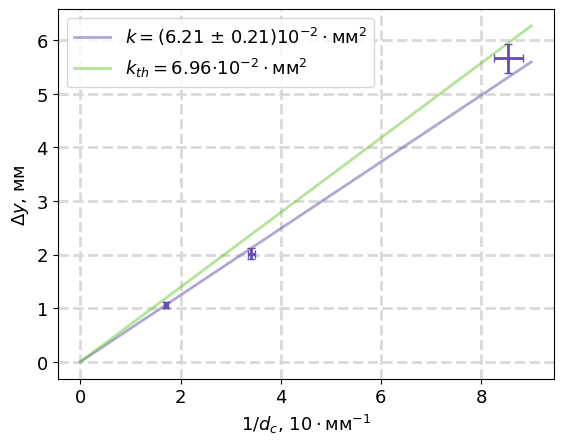

In [130]:
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)

popt, pcov = opt.curve_fit(linear0, 
                             dm, 
                             Dy, 
                             sigma = delta_Dy, 
                             absolute_sigma = True)
k = popt[0]
delta_k = delta_dm1/dm1 * k

k_th = lam * F2 * 1e-6 #mm^2
dm_th = np.linspace(0, 9)

plt.plot(dm_th, 10*k*dm_th,
         color = dark_purple, alpha = 0.5,
         label = r"$k = ($" + f"{k*1e2:.2f}" + r' $\pm$ ' + f"{delta_k*1e2:.2f}" + r'$) 10^{-2}\cdot\text{мм}^2$')
plt.plot(dm_th, 10*k_th*dm_th,
         color = light_green, alpha = 0.5,
         label = r"$k_{th} =$" + f"{k_th*1e2:.2f}" + r'$\cdot10^{-2}\cdot\text{мм}^2$')

plt.errorbar(np.array(dm)/10, Dy, 
             xerr = np.array(delta_dm)/10, yerr = delta_Dy, 
             fmt = 'o', 
             capsize=3, 
             markersize = 2, 
             color = dark_purple)
plt.xlabel(r'$1/d_c$, $10 \cdot \text{мм}^{-1}$')
plt.ylabel(r'$\Delta y$, мм')
plt.legend()
delta_k
plt.savefig('pics/С1_plot.png', dpi=300)


C:\Users\user\AppData\Local\Temp\ipykernel_24228\3211430753.py:4: RuntimeWarning: invalid value encountered in divide
  return D/2/np.pi * np.sin(D/2 * u)/(D/2 * u)


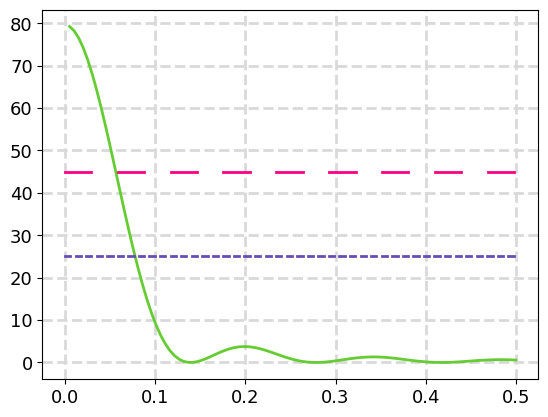

In [ ]:
plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)
D = 100 #mkm
def C(u): #u в mkm(-1)
    return D/2/np.pi * np.sin(D/2 * u)/(D/2 * u)

def f(x):
    return C(2 * np.pi/(lam * 1e-4)/(F2 * 1e4) * x)

x_th = np.linspace(0, 0.5, 100) #mm
plt.plot(x_th, f(x_th*1e3)**2/f(0.1), color = light_green)
x = 0
while (x < 0.5):
    plt.plot([x, x + 1/2/dm1], [25, 25], color = dark_purple)
    x += 1/dm1
x = 0
while (x < 0.5):
    plt.plot([x, x + 1/2/dm3], [45, 45], color = raspberry_pink)
    x += 1/dm3
